Goal: Use unsupervised machine learning (clustering) to identify patterns or groupings in the job postings dataset, based on variables such as required skills,job tittle, and salary.


In [1]:
import plotly.express as px
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.sql import SparkSession
import pandas as pd
import plotly.io as pio
from pyspark.sql.functions import avg

##Step 1: Load Data and Select Features

In [2]:
#| echo: true
#| eval: true
# Initialize Spark Session
spark = SparkSession.builder.appName("LightcastData").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
# Load Data
df = spark.read.option("header", "true").option("inferSchema", "true").option("multiLine","true").option("escape", "\"").csv("lightcast_job_postings.csv")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/22 14:32:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Step 2: Clean Data

In [3]:
from pyspark.sql.functions import trim,col
df = df.dropna(subset=["TITLE_RAW", "SKILLS_NAME", "SALARY"])
df = df.filter(trim(col("TITLE_RAW")) != "")

Step 3:Encode Job Titles (StringIndexer + OneHotEncoder)

In [4]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
title_indexer = StringIndexer(inputCol="TITLE_RAW", outputCol="TITLE_IDX")
title_encoder = OneHotEncoder(inputCol="TITLE_IDX", outputCol="TITLE_VEC")

Step 4: Extract Key Skills into Binary Flags

In [5]:
from pyspark.sql.functions import col
common_skills = ["SQL", "Python", "Excel", "Tableau", "Communication"]
for skill in common_skills:
    df = df.withColumn(f"SKILL_{skill}", col("SKILLS_NAME").contains(skill).cast("int"))

Step 5: Assemble Features for Clustering

In [6]:
assembler = VectorAssembler(
    inputCols=["SALARY", "TITLE_VEC"] + [f"SKILL_{s}" for s in common_skills],
    outputCol="features"
)

Step 6: Run KMeans Clustering Pipeline

In [7]:
kmeans = KMeans(k=3, featuresCol="features", predictionCol="cluster")
pipeline = Pipeline(stages=[title_indexer, title_encoder, assembler, kmeans])
model = pipeline.fit(df)
df_clustered = model.transform(df)
df_clustered.select("TITLE_RAW", "SALARY", "SKILLS_NAME", "cluster").show()

+--------------------+------+--------------------+-------+
|           TITLE_RAW|SALARY|         SKILLS_NAME|cluster|
+--------------------+------+--------------------+-------+
|Comisiones de $10...| 92500|                  []|      1|
|SR Lead Data Analyst|110155|[\n  "Power BI",\...|      2|
|Sr. Marketing Ana...| 92962|[\n  "Salesforce"...|      1|
|        Data Analyst|107645|[\n  "Regression ...|      2|
|Power, Utilities ...|192800|[\n  "Design Spec...|      0|
|Sr. Enterprise Da...| 81286|[\n  "Data Archit...|      1|
| SAP FSCM Consultant|125900|[\n  "Profit Cent...|      2|
|Principal growth ...|170000|[\n  "Curiosity",...|      0|
|SR Lead Data Analyst|110155|[\n  "Power BI",\...|      2|
|Senior Enterprise...|136950|[\n  "Wireless Co...|      2|
|      DATA ANALYTICS|118560|[\n  "Databricks"...|      2|
|Security Enterpri...| 79000|[\n  "Cryptograph...|      1|
|Sr BI Analyst/Dat...|140756|[\n  "Detail Orie...|      2|
|Power, Utilities ...|192800|[\n  "Design Spec...|      

Step7:Cluster-wise Analysis of Job Titles and Key Skills

In [13]:
df_clustered.groupBy("cluster", "TITLE_RAW").count().orderBy("cluster", "count", ascending=False).show(20)
df_clustered.groupBy("cluster").agg(
    *[avg(f"SKILL_{s}").alias(f"avg_{s}") for s in common_skills]
).show()

+-------+--------------------+-----+
|cluster|           TITLE_RAW|count|
+-------+--------------------+-----+
|      2|        Data Analyst|  407|
|      2|Enterprise Architect|  156|
|      2| Senior Data Analyst|  150|
|      2|Oracle HCM Cloud ...|  117|
|      2|Business Intellig...|   85|
|      2|  Solution Architect|   83|
|      2|GPS Oracle Referr...|   78|
|      2|SAP SuccessFactor...|   72|
|      2|SAP SuccessFactor...|   61|
|      2|        Data Modeler|   61|
|      2|Senior Enterprise...|   58|
|      2|Sr. Enterprise Da...|   56|
|      2|Oracle HCM Cloud ...|   56|
|      2|Oracle HCM Cloud ...|   55|
|      2|Salesforce Architect|   55|
|      2|Staff Strategy an...|   54|
|      2|Oracle Cloud AMS ...|   54|
|      2|Senior Engineer, ...|   53|
|      2|Data Analyst, Eng...|   52|
|      2|Black Lotus Labs ...|   52|
+-------+--------------------+-----+
only showing top 20 rows



+-------+-------------------+-------------------+------------------+-------------------+------------------+
|cluster|            avg_SQL|         avg_Python|         avg_Excel|        avg_Tableau| avg_Communication|
+-------+-------------------+-------------------+------------------+-------------------+------------------+
|      1| 0.4020368574199806|0.18380213385063046|0.3274329130294213|               0.25| 0.542192046556741|
|      2| 0.3585248763456503|0.19144602851323828|0.1322374163514693|0.18562700029095142| 0.555353505964504|
|      0|0.18621575342465754|0.15732020547945205|0.1500428082191781| 0.0646404109589041|0.5832619863013698|
+-------+-------------------+-------------------+------------------+-------------------+------------------+



Step 8: Visualize Salary Distribution by Cluster

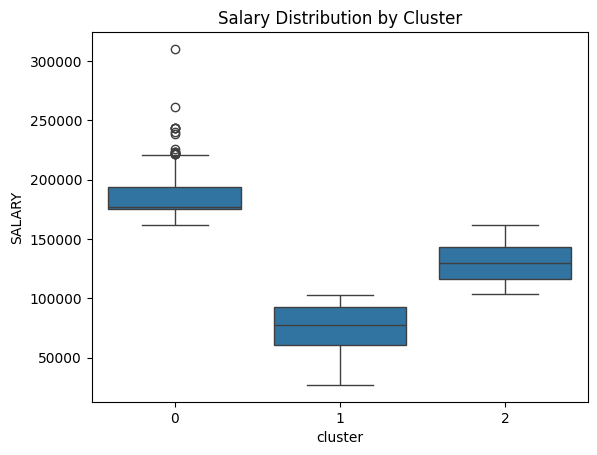

In [10]:
#| echo: false
#| fig-cap: "Salary Distribution by Cluster"
plot_df = df_clustered.select("SALARY", "cluster").limit(1000).toPandas()
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x="cluster", y="SALARY", data=plot_df)
plt.title("Salary Distribution by Cluster")
plt.savefig("salary_by_cluster.png", dpi=300)
plt.show()


Cluster 0 represents the highest-paying group among the three clusters. The median salary is around $180,000, and most values fall between $160,000 and $200,000. There are also several high outliers, with some positions exceeding $300,000. This cluster likely includes executive-level or highly technical roles, such as senior data scientists, lead data analysts, or enterprise architects, where specialized skills and extensive experience are required.

Cluster 1 is the lowest-paying group, with salaries concentrated between $60,000 and $100,000. The median is around $80,000, and the distribution is relatively tight compared to the other clusters. This group probably corresponds to entry-level or support roles, such as junior analysts, administrative data roles, or positions that require fewer years of experience and basic technical skills.

Cluster 2 falls between the other two in terms of salary, with most values ranging from $110,000 to $150,000. The median salary is approximately $130,000. This group likely represents mid-level professionals — positions requiring a balance of technical proficiency and industry experience. Common roles in this cluster might include mid-level data analysts, business intelligence specialists, or consultants with niche skill sets.

**Key Insights**

The salary clustering reveals three distinct tiers that correspond closely to career progression in business analytics and data science. The entry-level cluster (Cluster 1) shows a tight salary range of $60 K–$100 K (median ≈$80 K), indicating homogeneous roles with similar skill requirements. The mid-level cluster (Cluster 2) spans $110 K–$150 K (median ≈$130 K), reflecting professionals who combine technical proficiency with domain experience. The senior/executive cluster (Cluster 0) has a median around $180 K and a wide interquartile range, with outliers above $300 K—highlighting the premium placed on leadership, specialized machine-learning expertise, and high-impact strategic roles. Increasing dispersion at higher levels underscores that advanced specializations and demonstrated impact drive outsized compensation in this field.

**Recommendations**

For those entering the field, focus on mastering core tools (Python/R, SQL) and building a portfolio of projects—internships, Kaggle competitions, or open-source contributions—to stand out within the $60 K–$100 K band. Mid-career professionals should deepen domain knowledge (e.g., finance, healthcare, supply chain) and acquire advanced ML and MLOps skills to advance into the $110 K–$150 K range. Aspiring senior leaders must cultivate niche expertise (deep learning architectures, AI ethics, data engineering at scale) and demonstrate leadership through cross-functional project ownership or team management to access the high-variance $160 K+ opportunities. Earning recognized certifications (AWS/GCP ML, CAP) and staying current with emerging trends will further accelerate progression across these clusters.